##### top

# FMP modelling for Figure 3 (Cue stimulus)

This notebook runs Bayesian models on Datasets 3 (dataset with randomising cue stimulus) that is described in the article to assess interaction between perception and memory difficulty levels in the FMP and to assess the effect of cue stimulus. We fit the following formulas to mean score within the condition. Throughout the notebook, I use `task` as a term for memory difficulty levels (M, UD, FD-e), `difficulty` as a term for perceptual difficulty levels (1, 2, 3), and `userID` as a variable denoting individual participants. It is the exact same principle and code as the `FMP_fit_linear_regression-Figure3-cue_stimulus_separate.ipynb` but it sets the FM as a reference level instead of UD.

Unlike in `FMP_fit_linear_regression-Figure3-cue_stimulus.ipynb`, here we first separate the datasets according to the cue stimulus (`target_loc_simple` labels the morphing status of the cue stimulus; unmorphed = `target_0`, morphed = `other`) and subsequently fit models as before.


* Model task and difficulty interaction with user as a random effect. Equation:
    * _correct_flt ~ task * difficulty + (1|userID)_
* Model task and difficulty as main effects without interaction with user as a random effect. Equation:
    * _correct_flt ~ task + difficulty + (1|userID)_



We model mean accuracy per participant per condition.


* [Models](#Models)
* [Plot results](#Plot-results)
* [Compare all data](#Compare-all-data)
* [Save the inference](#Save-the-inference)


In [1]:
import os, sys
import pickle
from os.path import join as opj
import arviz as az
import bambi as bmb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

az.style.use("arviz-darkgrid")
SEED = 7355608


# Importing module for functions
functions_modul =  "./functions"
sys.path.insert(0, functions_modul)

# import all processing and plotting functions
from bayesian_modelling_functions import fit_model, print_model

path_general = "../"
path_data = opj(path_general, "Data", "datasets")
path_inference_data = opj(path_general, "Data", "model_inference_data")


# set the numer of CPU
num_cpu = min(4, os.cpu_count()-1)
print(f'We will have {num_cpu} cores.\n')

path_dic = {
#     'dataset_1' : opj(path_data, 'FMP_dataset_1.csv'),
#     'dataset_2': opj(path_data, 'FMP_dataset_2.csv'),
    'dataset_3': opj(path_data, 'FMP_dataset_3.csv'),
#     'concat_datasets_123': opj(path_data, 'FMP_concat_datasets_123.csv'),
#     'dataset_4': opj(path_data, 'FMP_dataset_4.csv'),
}


# load all dataframes
df_dic = {}

# only selected cols
select_cols = ['stim1', 'stim2', 'target', 'RT', 'userID', 'difficulty', 'levels', 'task', 'correct_flt', 'order']


for f in path_dic.keys():   
    if 'dataset_3' in f:
        df_dic[f] = pd.read_csv(path_dic[f], usecols=select_cols+['target_loc', 'target_loc_simple'])
    else:
        df_dic[f] = pd.read_csv(path_dic[f], usecols=select_cols)
    
    df_dic[f]["Experiment"] = f
        

    # clean
    df_dic[f].reset_index(drop=True, inplace=True)
    
    if 'Unnamed: 0' in df_dic[f].columns:
        df_dic[f].drop('Unnamed: 0', inplace=True, axis=1)
        
    
    # find low performing participants
    tt = df_dic[f].loc[df_dic[f]['task'].isin(['face matching', 'perc', 'perception'])].groupby(['userID', 'difficulty']).correct_flt.mean()

    drop_ptc = tt[tt<=0.5].reset_index().userID.values
    print(f'\nIn {f} dropping {len(drop_ptc)} participants for low accuracy in FM.')
    print(tt[tt<=0.5])

    # and remove them
    df_dic[f] = df_dic[f].loc[~df_dic[f]['userID'].isin(drop_ptc)]
    # clean up
    drop_ptc, tt = None, None
    
    print(f"\nThere is now N={df_dic[f]['userID'].unique().size} participants in {f}.")



#####
# rename the levels
rename_tasks_dic = {'perception':'Matching', 'perc':'Matching', 'blank':'Unfilled Delay', 'faces':'Filled Delay - emotions', 'math':'Filled Delay - math'}

# define orders
hue_order = ['Matching', 'Unfilled Delay', 'Filled Delay - emotions']
hue_order_math = ['Matching', 'Unfilled Delay', 'Filled Delay - emotions', 'Filled Delay - math']



# rename the memory task labels in the df
for f in df_dic.keys():
    if f=='noise':
        continue
    df_dic[f]['task'] = df_dic[f]['task'].map(rename_tasks_dic).fillna(df_dic[f]['task'])

    
    
# add two datasets for the longitudinal split based on cue stimuli (target) location
# take only other -> morphed
df_dic['dataset_3_other'] = df_dic['dataset_3'].loc[df_dic['dataset_3']['target_loc_simple']=='other'].copy()

# take only target 0 -> unmorphed
df_dic['dataset_3_target_0'] = df_dic['dataset_3'].loc[df_dic['dataset_3']['target_loc_simple']=='target_0'].copy()


We will have 4 cores.


In dataset_3 dropping 0 participants for low accuracy in FM.
Series([], Name: correct_flt, dtype: float64)

There is now N=262 participants in dataset_3.


In [2]:
# select only specific datasets and prepare them
datasets2fit = ['dataset_3_other', 'dataset_3_target_0']

df_dic_fit = {}


for f in datasets2fit:
    data=None
    
    # groupby and make means for ptc and condition
    data = df_dic[f].groupby(['userID', 'task', 'difficulty'], observed=False).correct_flt.mean().reset_index()

    # convert all variables to categories
    # categorical_cols = data.columns[data.dtypes == object].tolist() + ['difficulty']
    categorical_cols = ['userID', 'task', 'difficulty']
    for col in categorical_cols:
        if col == 'task':
            # specify the order that we want
            data[col] = pd.Categorical(data[col], categories=['Unfilled Delay', 'Matching', 'Filled Delay - emotions'], ordered=True)
            #['Unfilled Delay', 'Matching', 'Filled Delay - emotions']
            
            # also do it for the original datasets
            df_dic[f][col] = pd.Categorical(df_dic[f][col], categories=['Unfilled Delay', 'Matching', 'Filled Delay - emotions'], ordered=True)
        else:
            data[col] = data[col].astype("category")
            df_dic[f][col] = df_dic[f][col].astype("category")

    # check
    print('\n',f)
    df_dic[f].info()
        
    # save
    df_dic_fit[f] = data.copy()

# # drop them for now
# data[data.correct_flt.isna()]


 dataset_3_other
<class 'pandas.core.frame.DataFrame'>
Index: 12875 entries, 0 to 47158
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   stim1              12875 non-null  object  
 1   stim2              12875 non-null  object  
 2   target             12875 non-null  object  
 3   RT                 12517 non-null  float64 
 4   userID             12875 non-null  category
 5   task               12875 non-null  category
 6   order              12875 non-null  int64   
 7   difficulty         12875 non-null  category
 8   levels             12875 non-null  int64   
 9   correct_flt        12517 non-null  float64 
 10  target_loc_simple  12875 non-null  object  
 11  target_loc         12875 non-null  object  
 12  Experiment         12875 non-null  object  
dtypes: category(3), float64(2), int64(2), object(6)
memory usage: 1.1+ MB

 dataset_3_target_0
<class 'pandas.core.frame.DataFrame'>
Index: 34

## Model as means
[top](#top)

In [3]:
model_assumptions = {
    "correct_flt ~ task * difficulty + (1|userID)": "Each user has their own baseline performance, but the effect of task and difficulty is assumed to be the same across all users.",
    "correct_flt ~ task + difficulty + (1|userID)": "Assumes that each user has their own baseline performance, but the effects of task and difficulty are consistent across all users without any interaction between task and difficulty.",
}

# define what we want to run
base_lvl = ['Matching', 'Unfilled Delay', 'Filled Delay - emotions']
formulas2run = [
    "correct_flt ~ C(task, levels=base_lvl) * difficulty + (1|userID)",
    "correct_flt ~ C(task, levels=base_lvl) + difficulty + (1|userID)",
]

In [4]:
# define where we will store the results
model_dic_bernoulli = {}
result_dic_bernoulli = {}

for f in df_dic_fit.keys():
    print(f'\nFitting dataset {f}\n')
    # create datasets
    if f not in model_dic_bernoulli.keys():
        model_dic_bernoulli[f] = {}
    if f not in result_dic_bernoulli.keys():
        result_dic_bernoulli[f] = {}
    
    for formula in formulas2run:
        print(f'\nFitting formula {formula}\n')
    
        model_dic_bernoulli[f][formula], result_dic_bernoulli[f][formula] = fit_model(formula, df_dic_fit[f], 
                                                                                      categorical_cols, base_lvl=base_lvl,
                                                                                      num_cpu=num_cpu, check_priors=False, sample_priors=False)

Sampling 4 chains, 0 divergences ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 / 0:00:21

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 22 seconds.


In [5]:
model_dic_bernoulli[f][formulas2run[0]]

       Formula: correct_flt ~ C(task, levels=base_lvl) * difficulty + (1|userID)
        Family: gaussian
          Link: mu = identity
  Observations: 2343
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 0.7703, sigma: 0.7842)
            C(task, levels=base_lvl) ~ Normal(mu: [0. 0.], sigma: [0.8886 0.8929])
            difficulty ~ Normal(mu: [0. 0.], sigma: [0.89 0.89])
            C(task, levels=base_lvl):difficulty ~ Normal(mu: [0. 0. 0. 0.], sigma: [1.3313 1.3313 1.3426
                1.3426])
        
        
        Group-level effects
            1|userID ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 0.7842))
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 0.1678)
------
* To see a plot of the priors call the .plot_priors() method.
* To see a summary or plot of the posterior pass the object returned by .fit() to az.summary() or az.plot_trace()

In [6]:
model_dic_bernoulli[f][formulas2run[1]]

       Formula: correct_flt ~ C(task, levels=base_lvl) + difficulty + (1|userID)
        Family: gaussian
          Link: mu = identity
  Observations: 2343
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 0.7703, sigma: 0.7261)
            C(task, levels=base_lvl) ~ Normal(mu: [0. 0.], sigma: [0.8886 0.8929])
            difficulty ~ Normal(mu: [0. 0.], sigma: [0.89 0.89])
        
        Group-level effects
            1|userID ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 0.7261))
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 0.1678)
------
* To see a plot of the priors call the .plot_priors() method.
* To see a summary or plot of the posterior pass the object returned by .fit() to az.summary() or az.plot_trace()

### check priors

Sampling: [1|userID_sigma, C(task, levels=base_lvl), C(task, levels=base_lvl):difficulty, Intercept, difficulty, sigma]


array([[<Axes: title={'center': 'Intercept'}>,
        <Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'C(task, levels=base_lvl)\nUnfilled Delay'}>],
       [<Axes: title={'center': 'C(task, levels=base_lvl)\nFilled Delay - emotions'}>,
        <Axes: title={'center': 'difficulty\n2'}>,
        <Axes: title={'center': 'difficulty\n3'}>],
       [<Axes: title={'center': 'C(task, levels=base_lvl):difficulty\nUnfilled Delay, 2'}>,
        <Axes: title={'center': 'C(task, levels=base_lvl):difficulty\nUnfilled Delay, 3'}>,
        <Axes: title={'center': 'C(task, levels=base_lvl):difficulty\nFilled Delay - emotions, 2'}>],
       [<Axes: title={'center': 'C(task, levels=base_lvl):difficulty\nFilled Delay - emotions, 3'}>,
        <Axes: title={'center': '1|userID_sigma'}>, <Axes: >]],
      dtype=object)

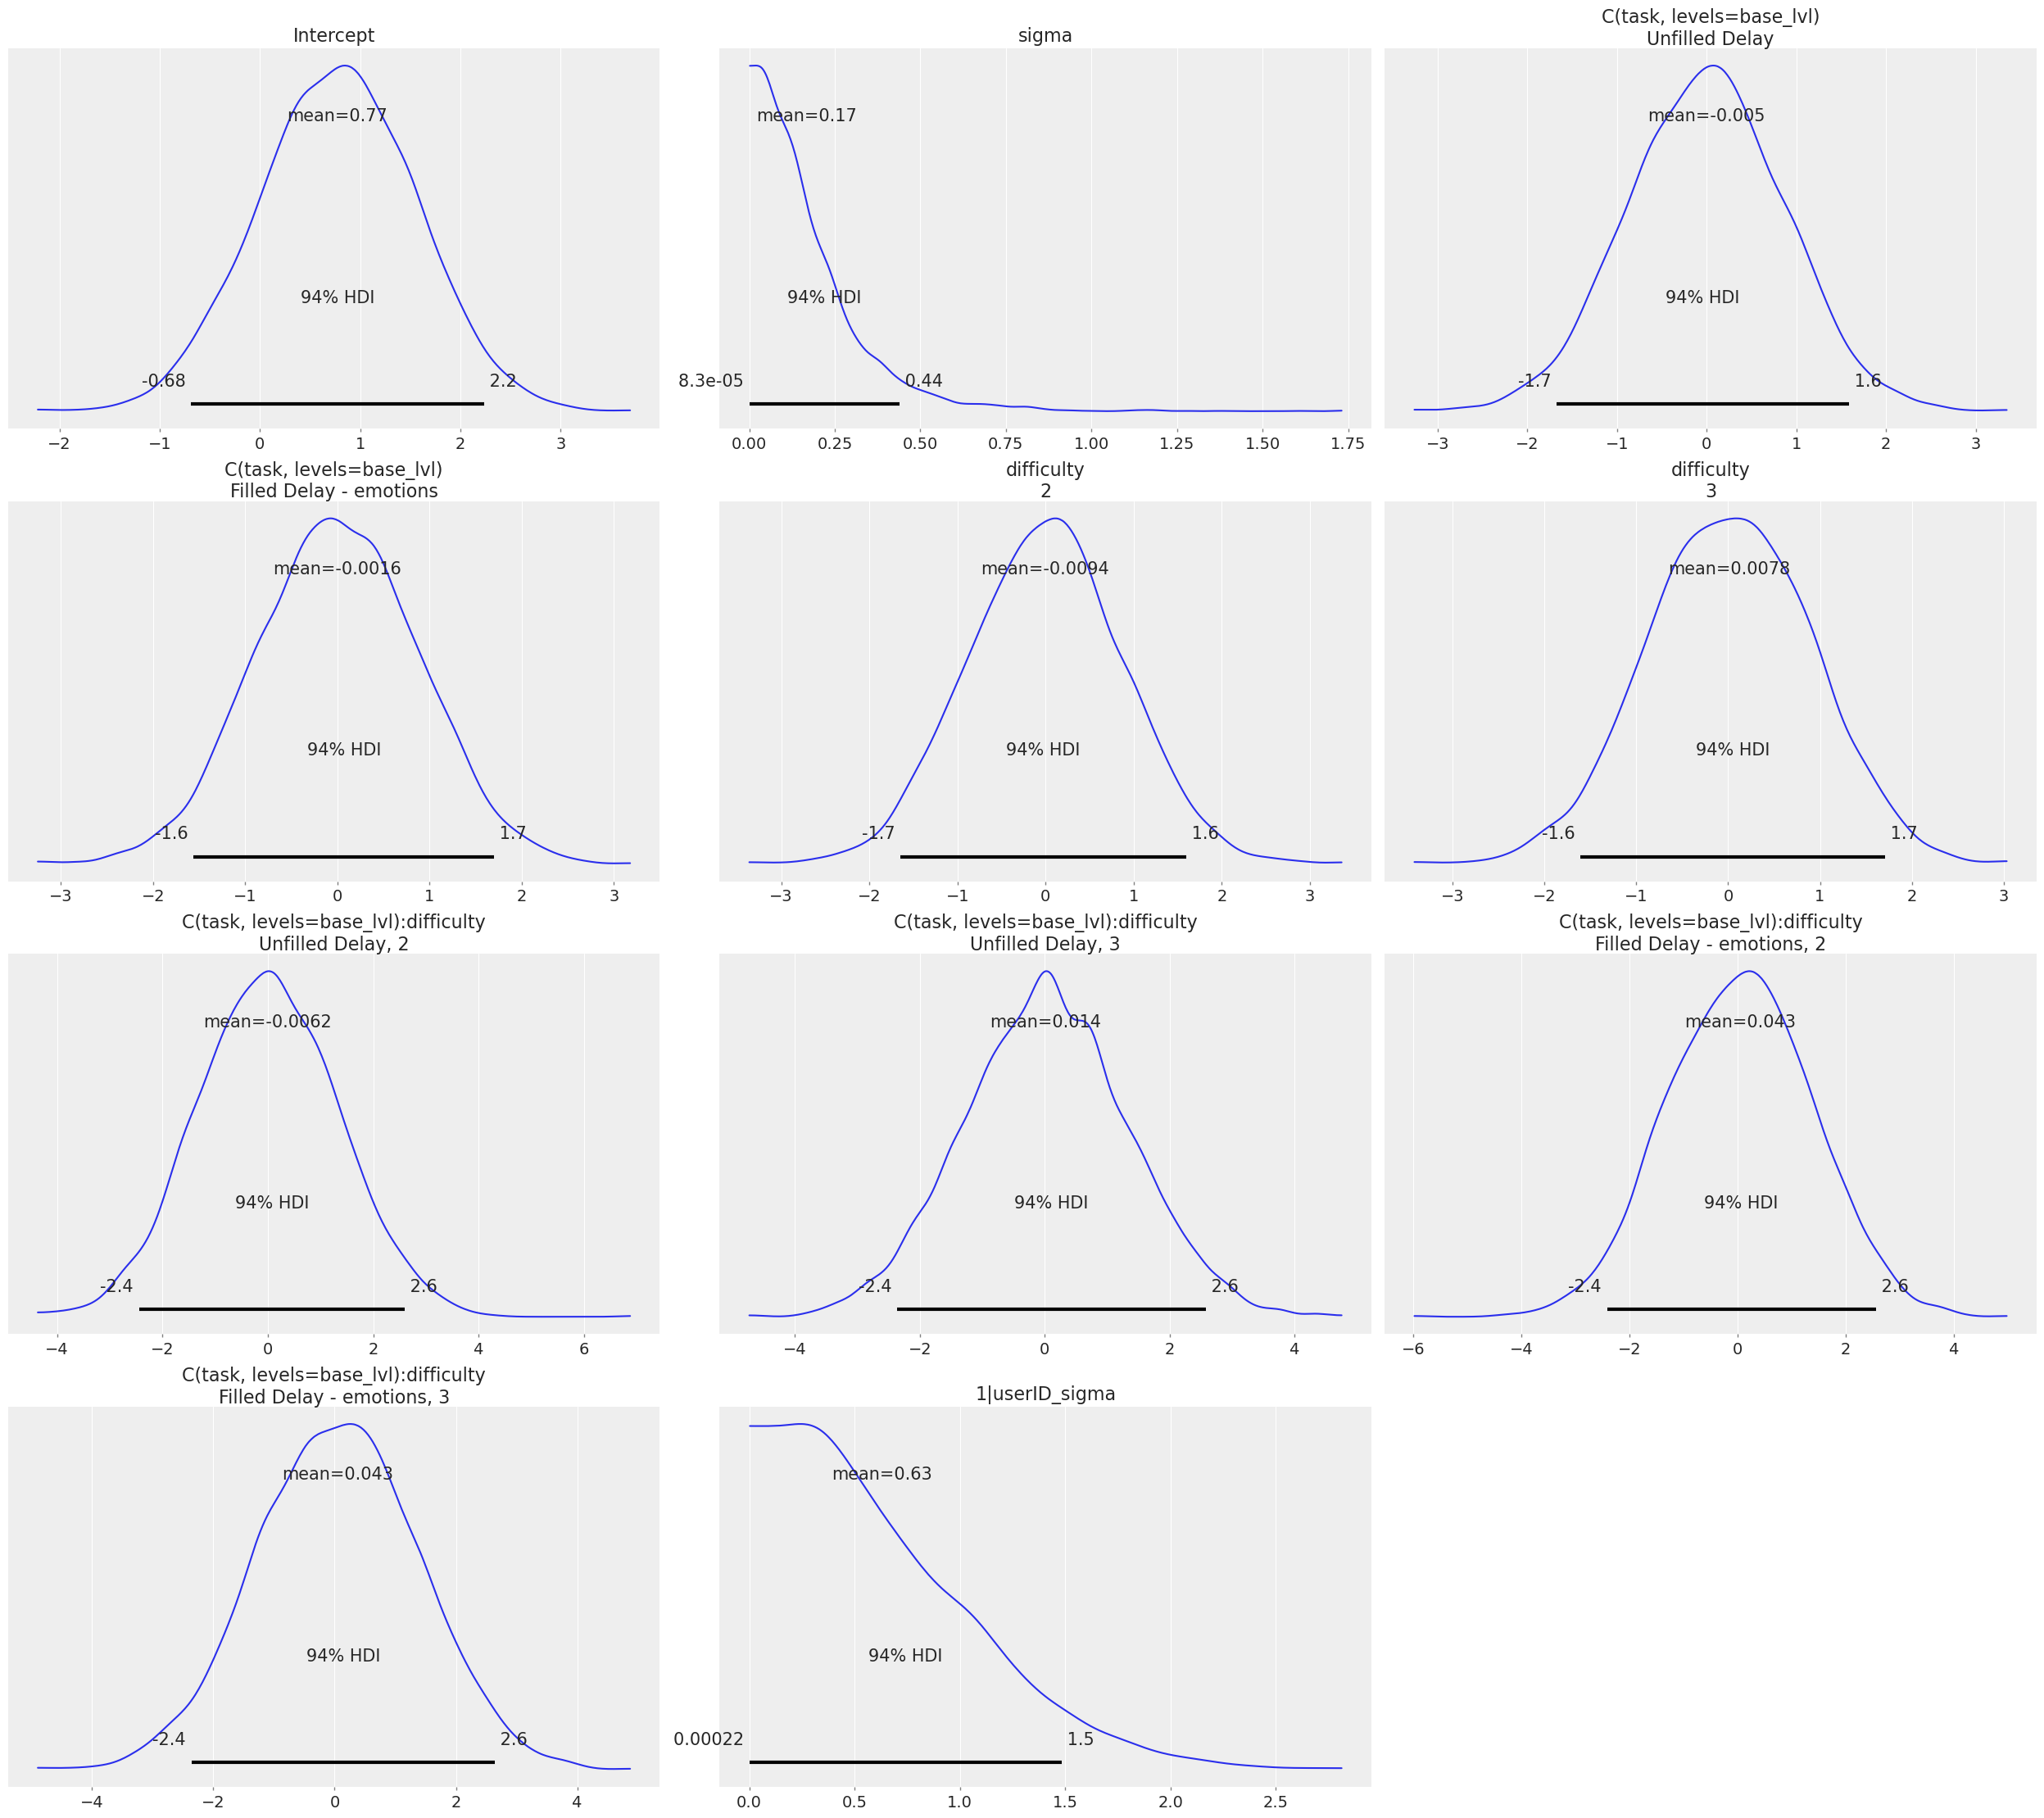

In [7]:
model_dic_bernoulli[f][formulas2run[0]].plot_priors()

Sampling: [1|userID_sigma, C(task, levels=base_lvl), Intercept, difficulty, sigma]


array([[<Axes: title={'center': 'Intercept'}>,
        <Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'C(task, levels=base_lvl)\nUnfilled Delay'}>],
       [<Axes: title={'center': 'C(task, levels=base_lvl)\nFilled Delay - emotions'}>,
        <Axes: title={'center': 'difficulty\n2'}>,
        <Axes: title={'center': 'difficulty\n3'}>],
       [<Axes: title={'center': '1|userID_sigma'}>, <Axes: >, <Axes: >]],
      dtype=object)

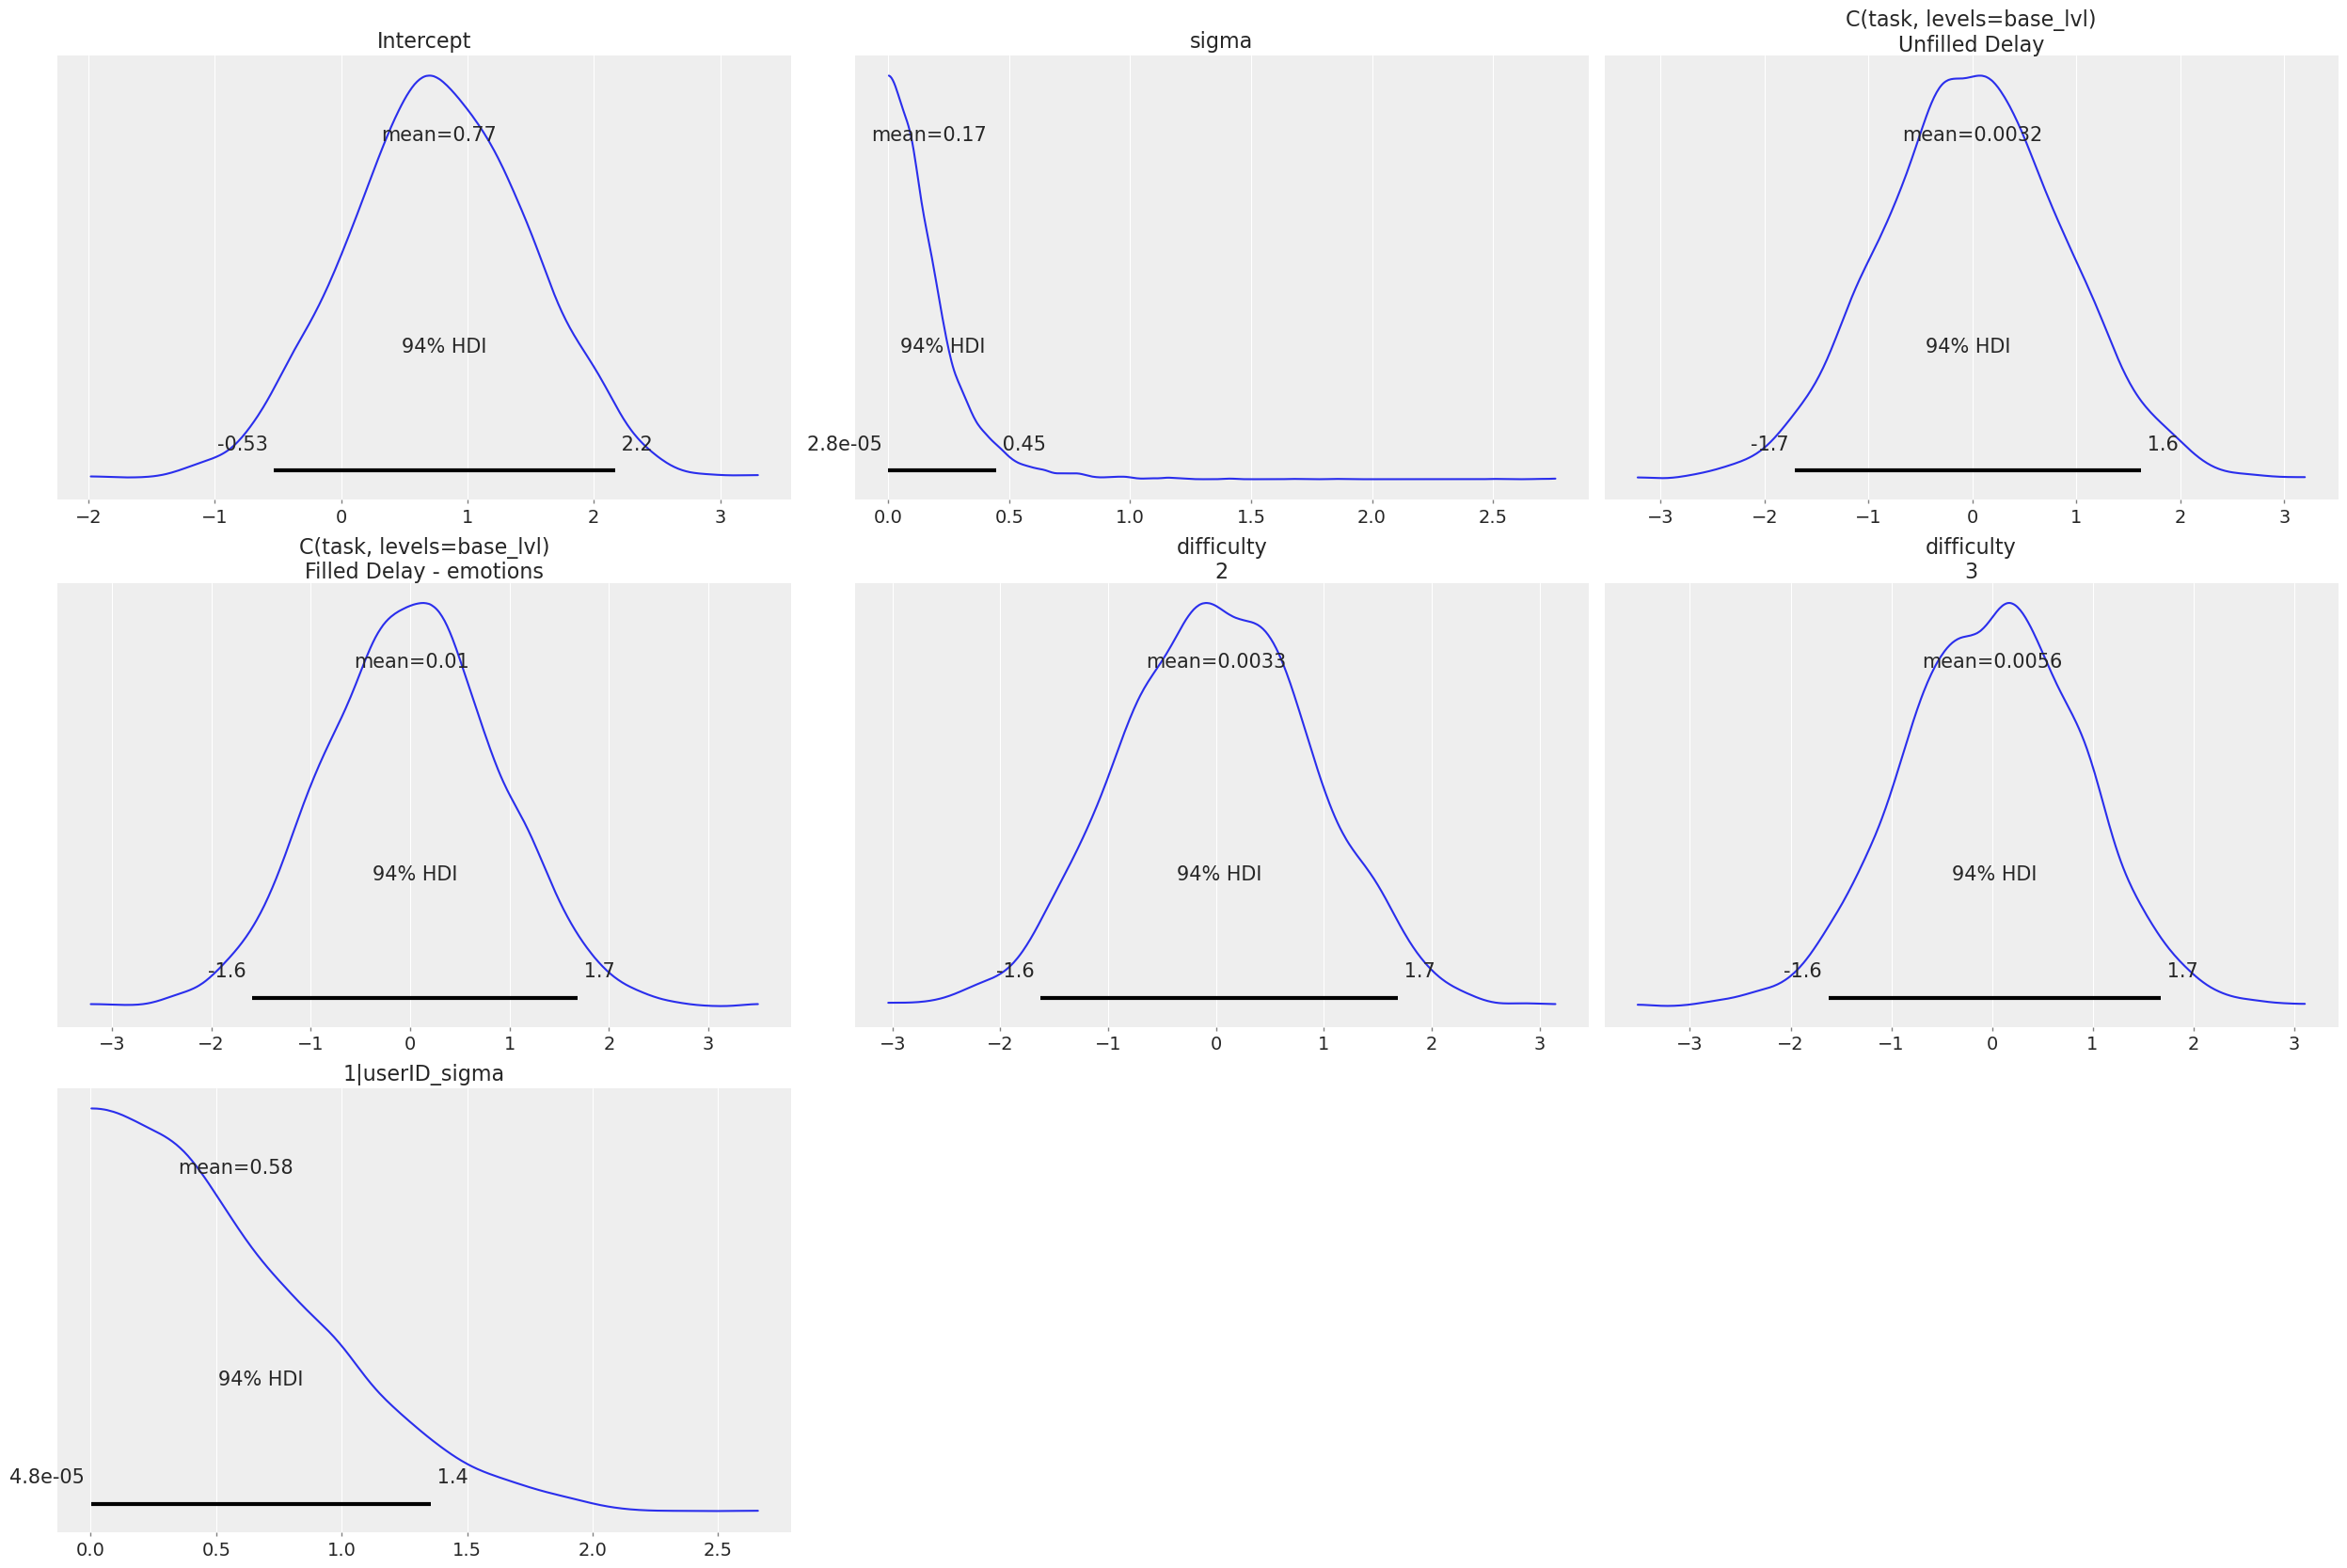

In [8]:
model_dic_bernoulli[f][formulas2run[1]].plot_priors()

### check posterior

array([[<Axes: title={'center': 'Intercept'}>,
        <Axes: title={'center': 'difficulty\n2'}>,
        <Axes: title={'center': 'difficulty\n3'}>],
       [<Axes: title={'center': 'C(task, levels=base_lvl)\nUnfilled Delay'}>,
        <Axes: title={'center': 'C(task, levels=base_lvl)\nFilled Delay - emotions'}>,
        <Axes: >]], dtype=object)

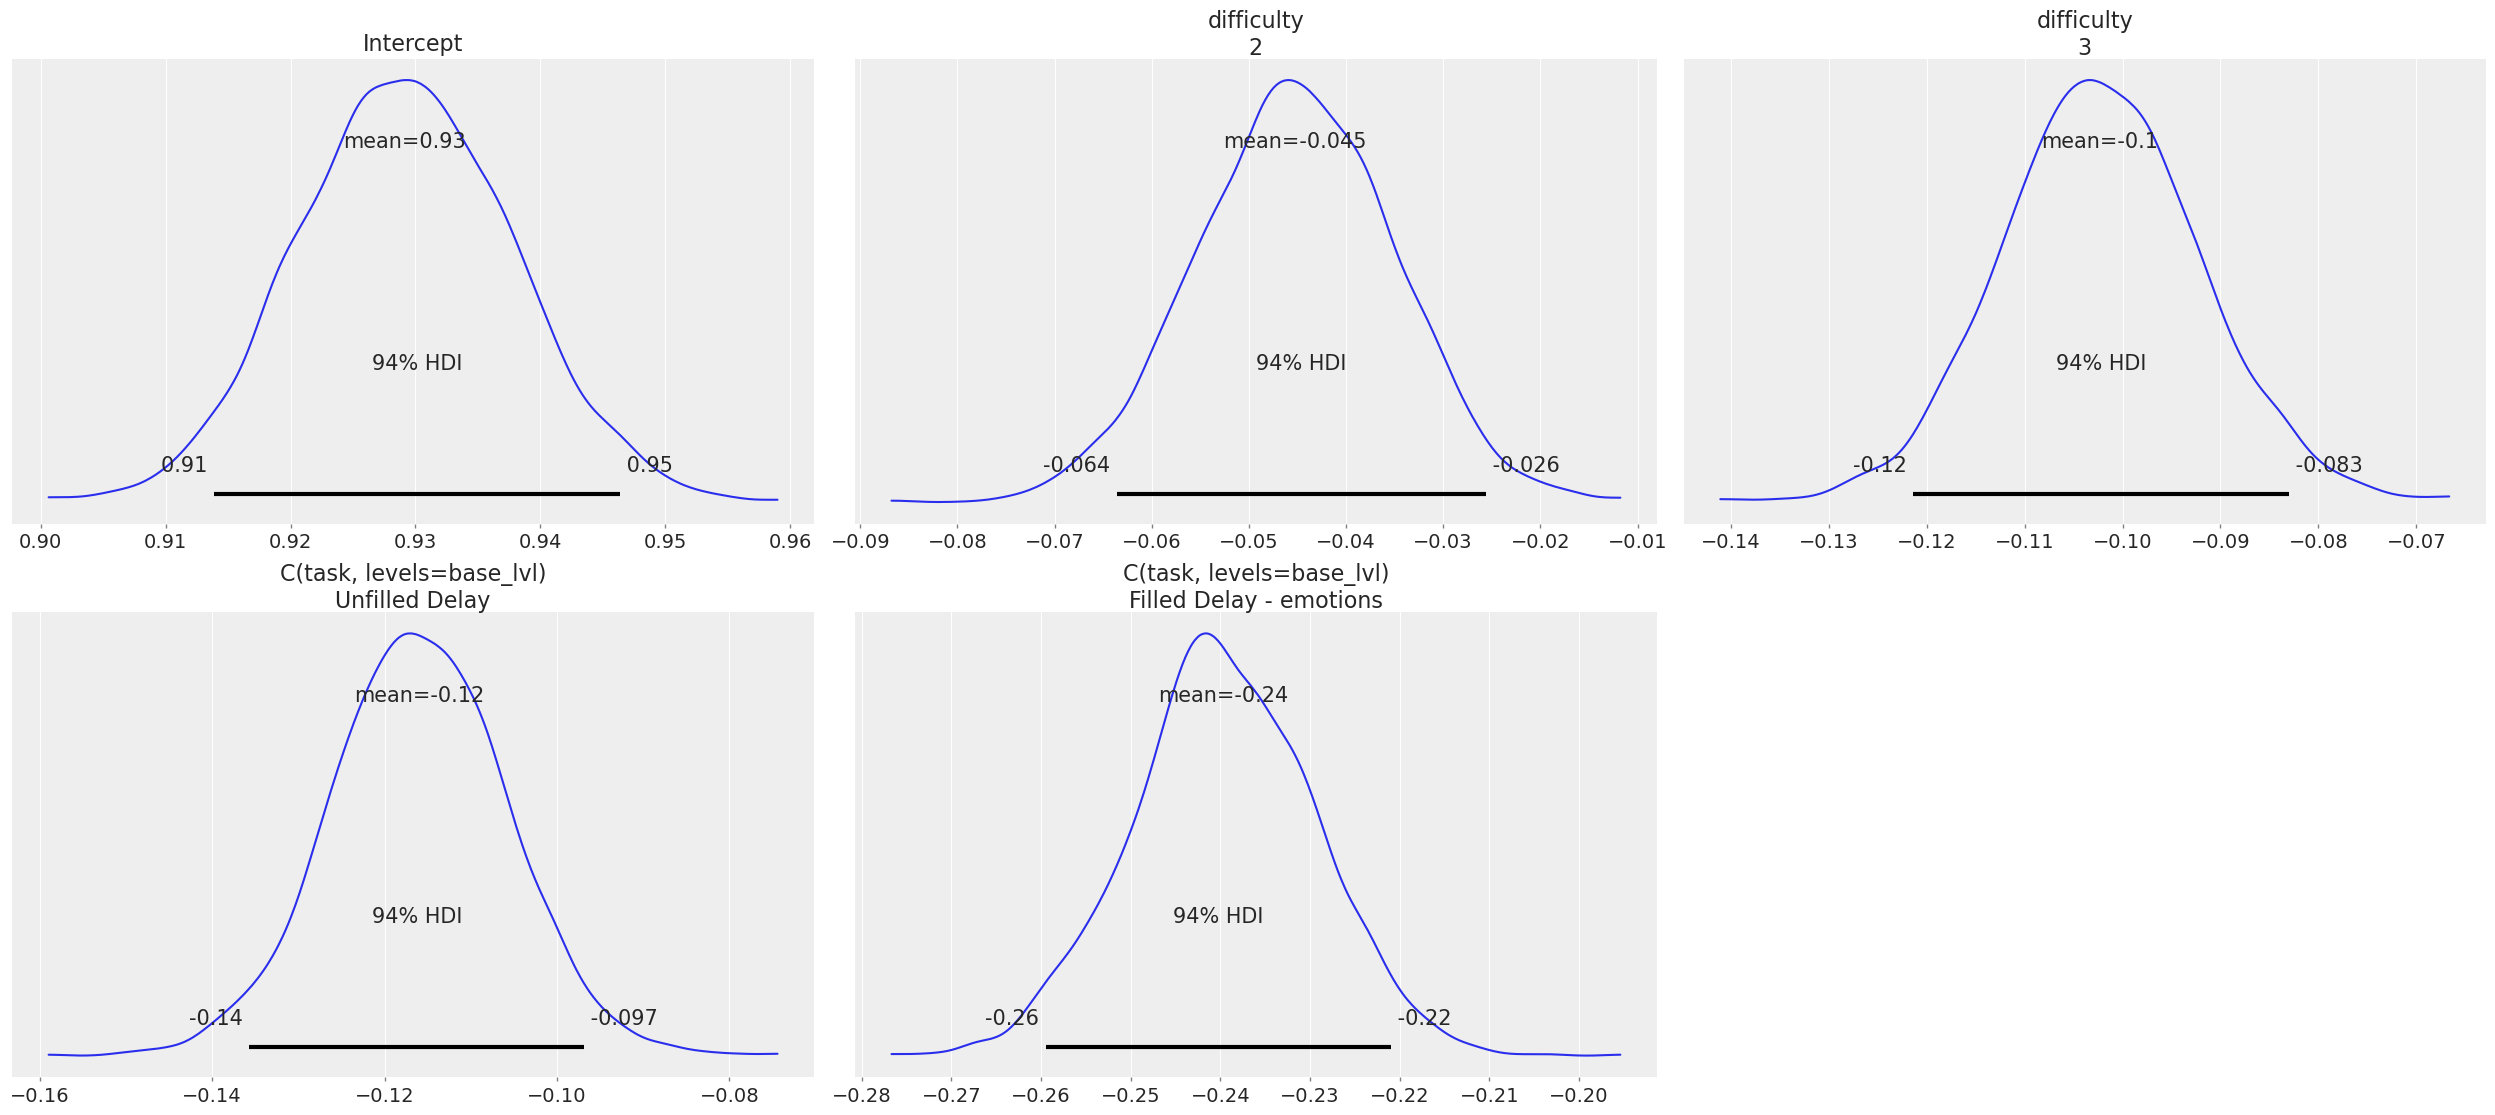

In [9]:
az.plot_posterior(result_dic_bernoulli[f][formulas2run[0]], 
                  var_names=['Intercept', 'difficulty', 'C(task, levels=base_lvl)'],#, 'task:difficulty'],
                  hdi_prob=.94)

array([[<Axes: title={'center': 'Intercept'}>,
        <Axes: title={'center': 'difficulty\n2'}>,
        <Axes: title={'center': 'difficulty\n3'}>],
       [<Axes: title={'center': 'C(task, levels=base_lvl)\nUnfilled Delay'}>,
        <Axes: title={'center': 'C(task, levels=base_lvl)\nFilled Delay - emotions'}>,
        <Axes: >]], dtype=object)

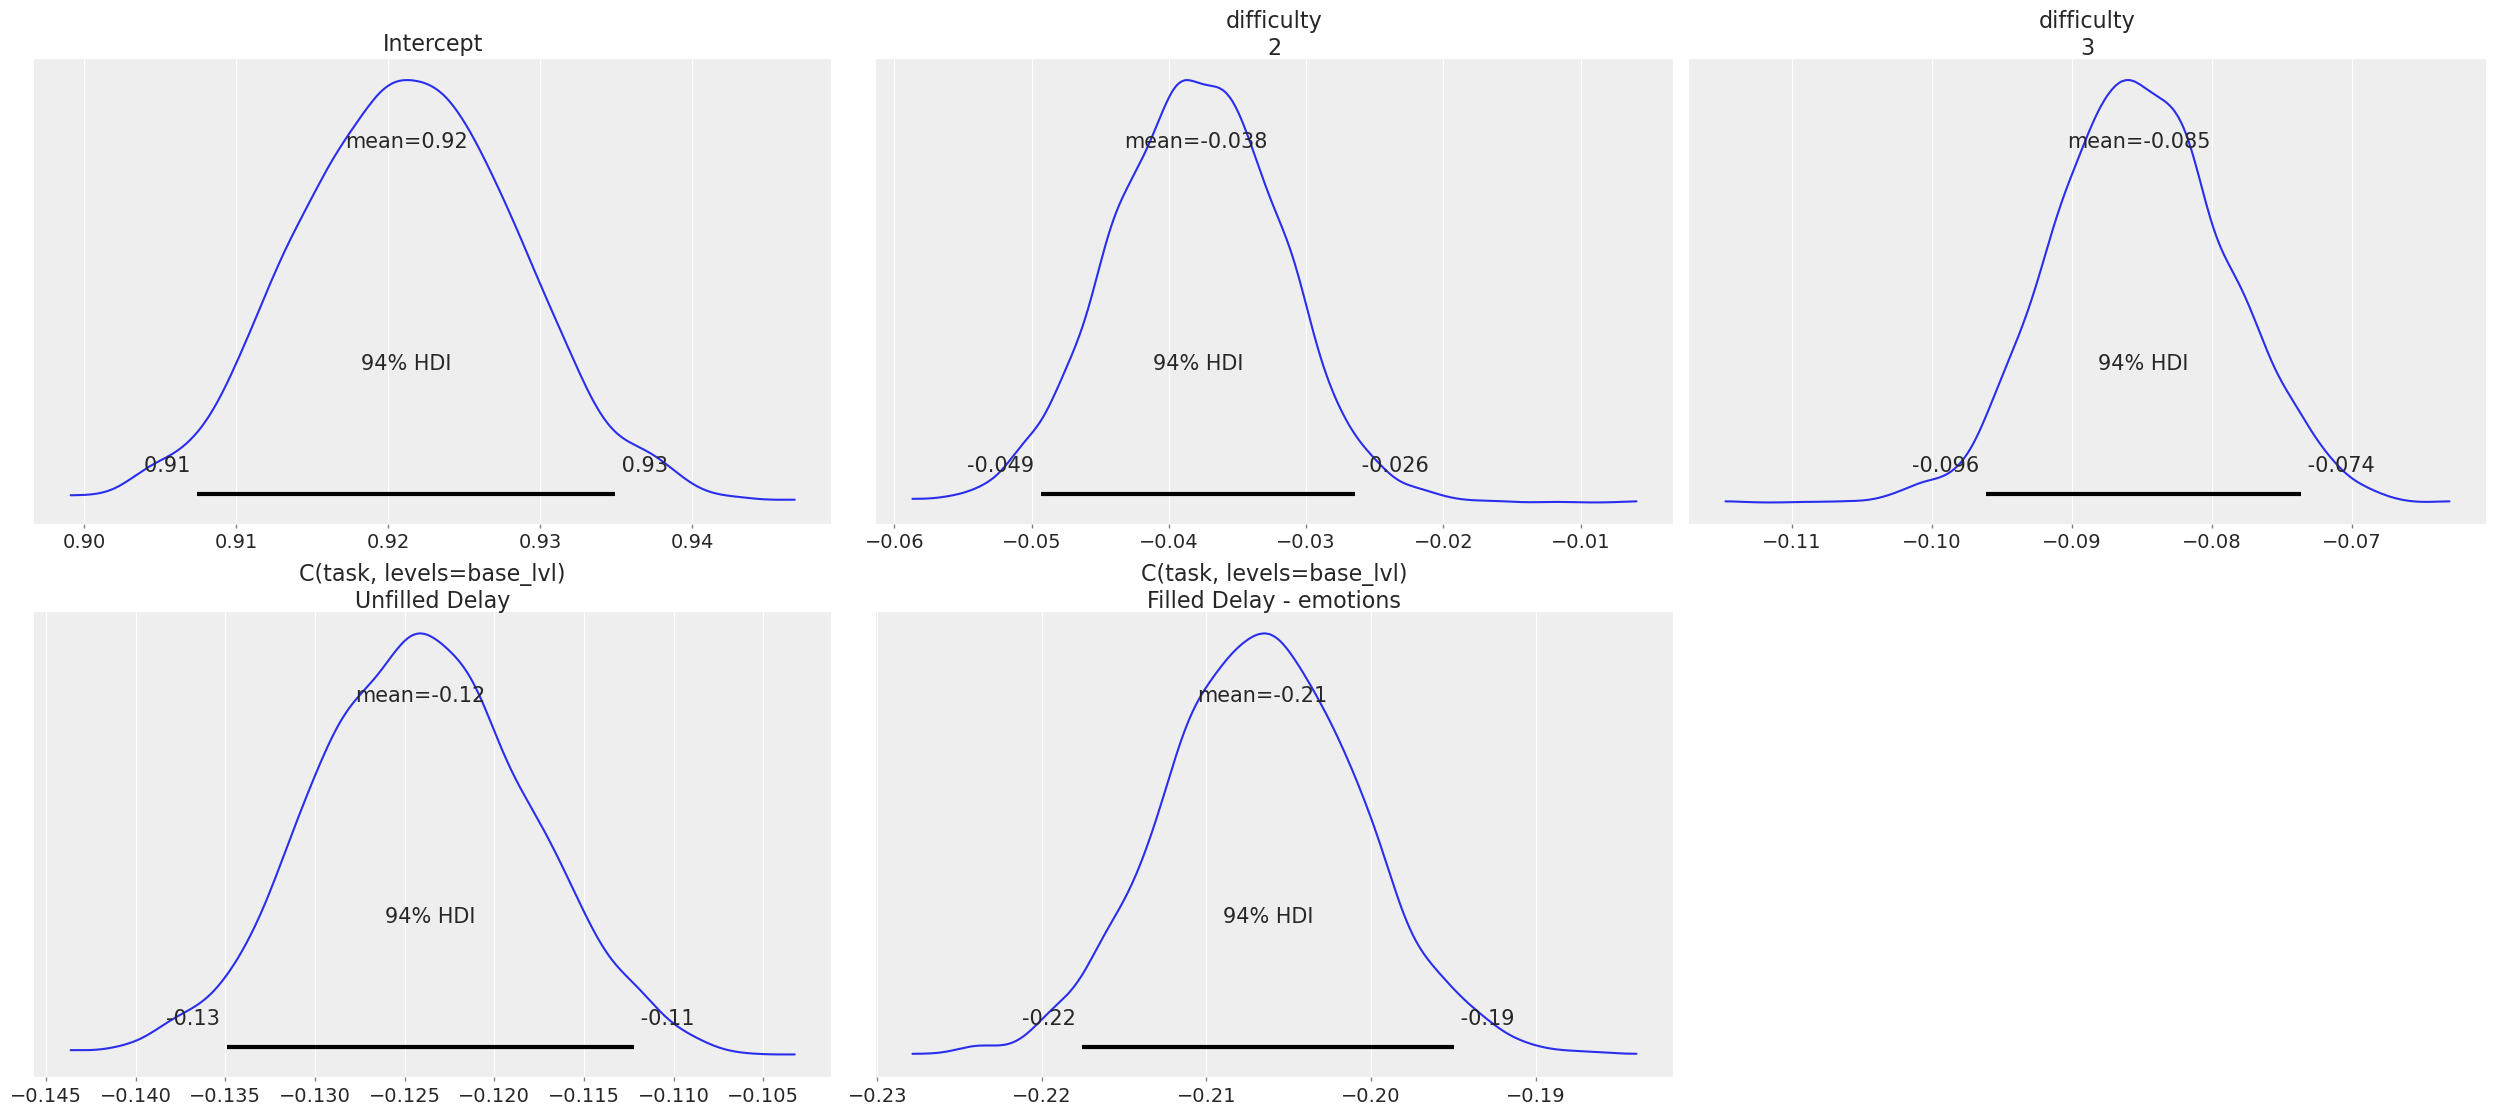

In [10]:
az.plot_posterior(result_dic_bernoulli[f][formulas2run[1]], 
                  var_names=['Intercept', 'difficulty', 'C(task, levels=base_lvl)'],#, 'task:difficulty'],
                  hdi_prob=.94)

---
## Plot results

## Dataset 3 - morphed image as cue stimulus
[top](#top)

Dataset: dataset_3_other

Fitting formula correct_flt ~ C(task, levels=base_lvl) * difficulty + (1|userID)



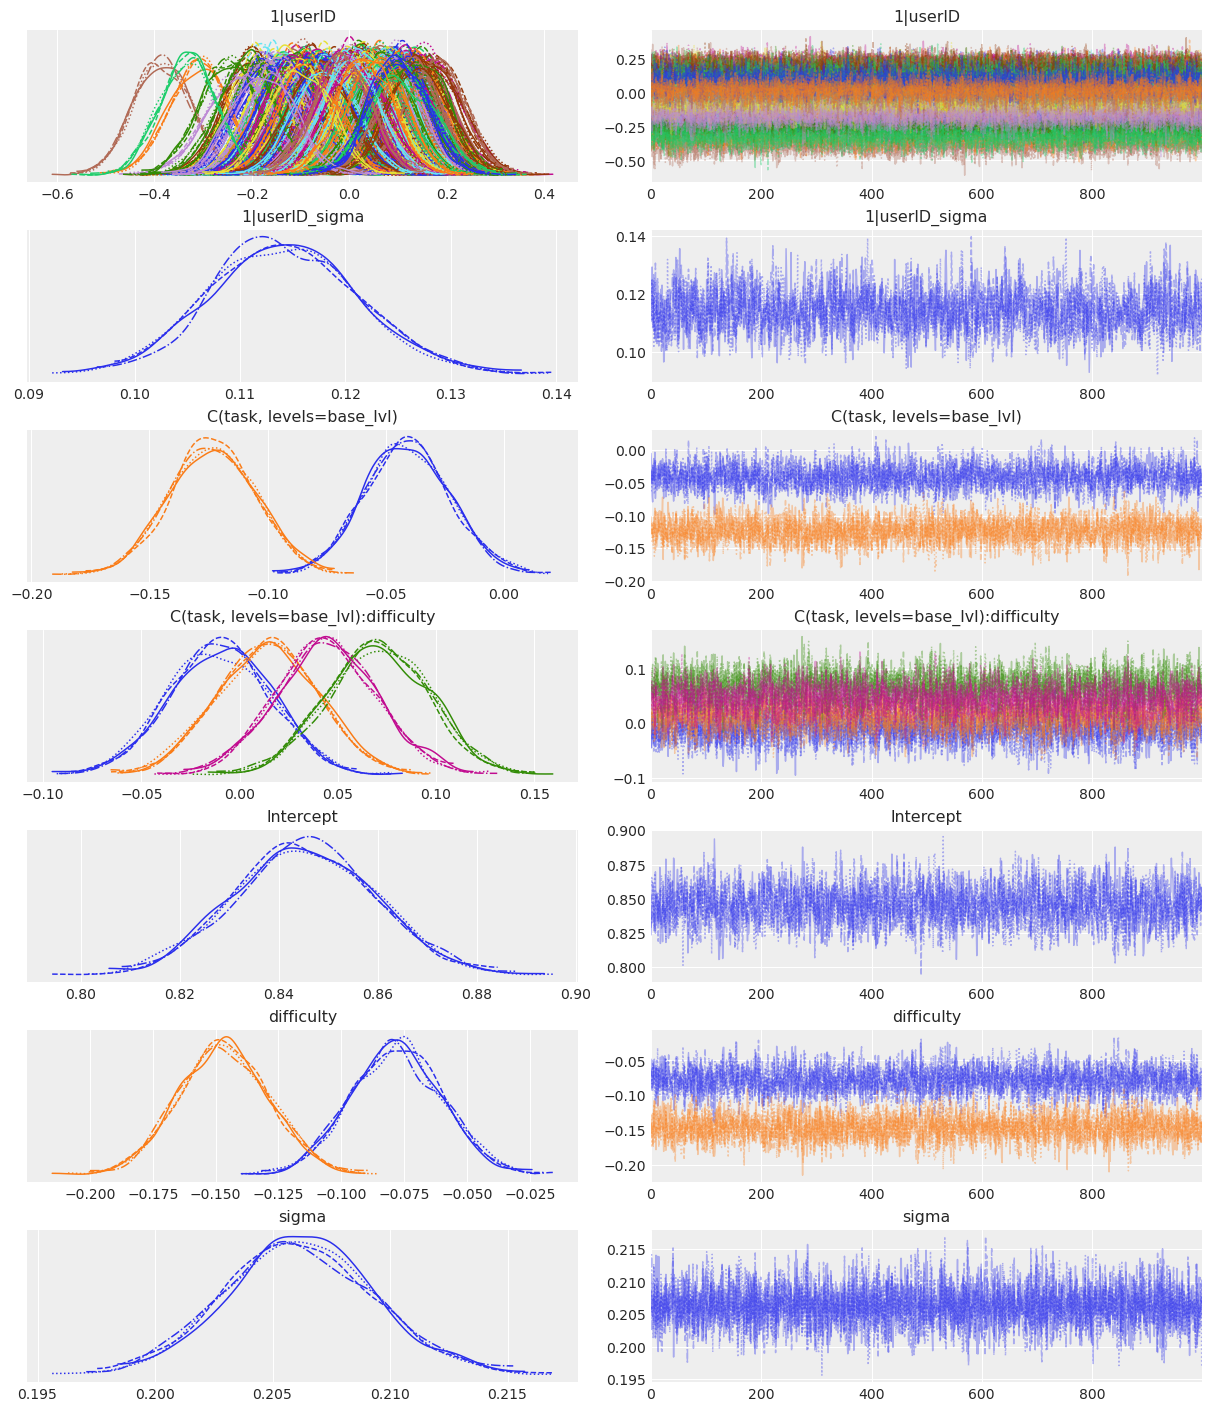

                   mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
1|userID[s_1001]  0.043  0.059  -0.065    0.156      0.001    0.001    8754.0   
1|userID[s_1002] -0.077  0.058  -0.191    0.031      0.001    0.001    8792.0   
1|userID[s_1006]  0.053  0.061  -0.060    0.165      0.001    0.001    8974.0   
1|userID[s_1012] -0.112  0.059  -0.225   -0.004      0.001    0.001    8504.0   
1|userID[s_1015]  0.013  0.059  -0.097    0.120      0.001    0.001    8720.0   
1|userID[s_1016]  0.026  0.059  -0.087    0.136      0.001    0.001    8353.0   
1|userID[s_1017] -0.112  0.059  -0.231   -0.008      0.001    0.001    7808.0   
1|userID[s_1036] -0.022  0.061  -0.140    0.089      0.001    0.001    9805.0   
1|userID[s_1042] -0.169  0.061  -0.286   -0.057      0.001    0.001    9171.0   
1|userID[s_1045]  0.117  0.059   0.008    0.229      0.001    0.001    8542.0   
1|userID[s_1046] -0.099  0.067  -0.225    0.027      0.001    0.001    8381.0   
1|userID[s_1047]  0.071  0.0

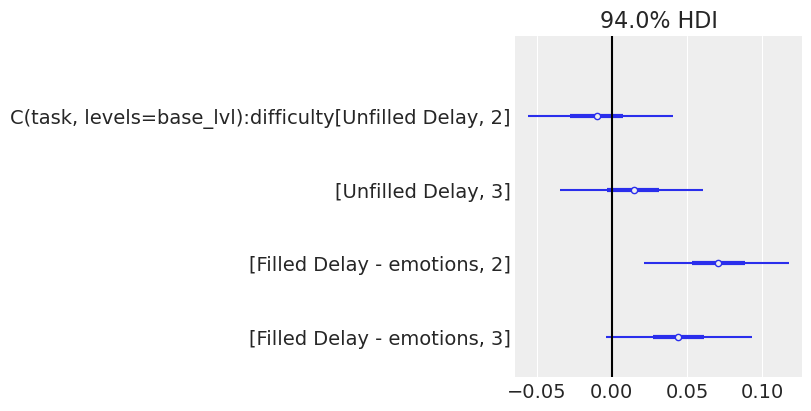

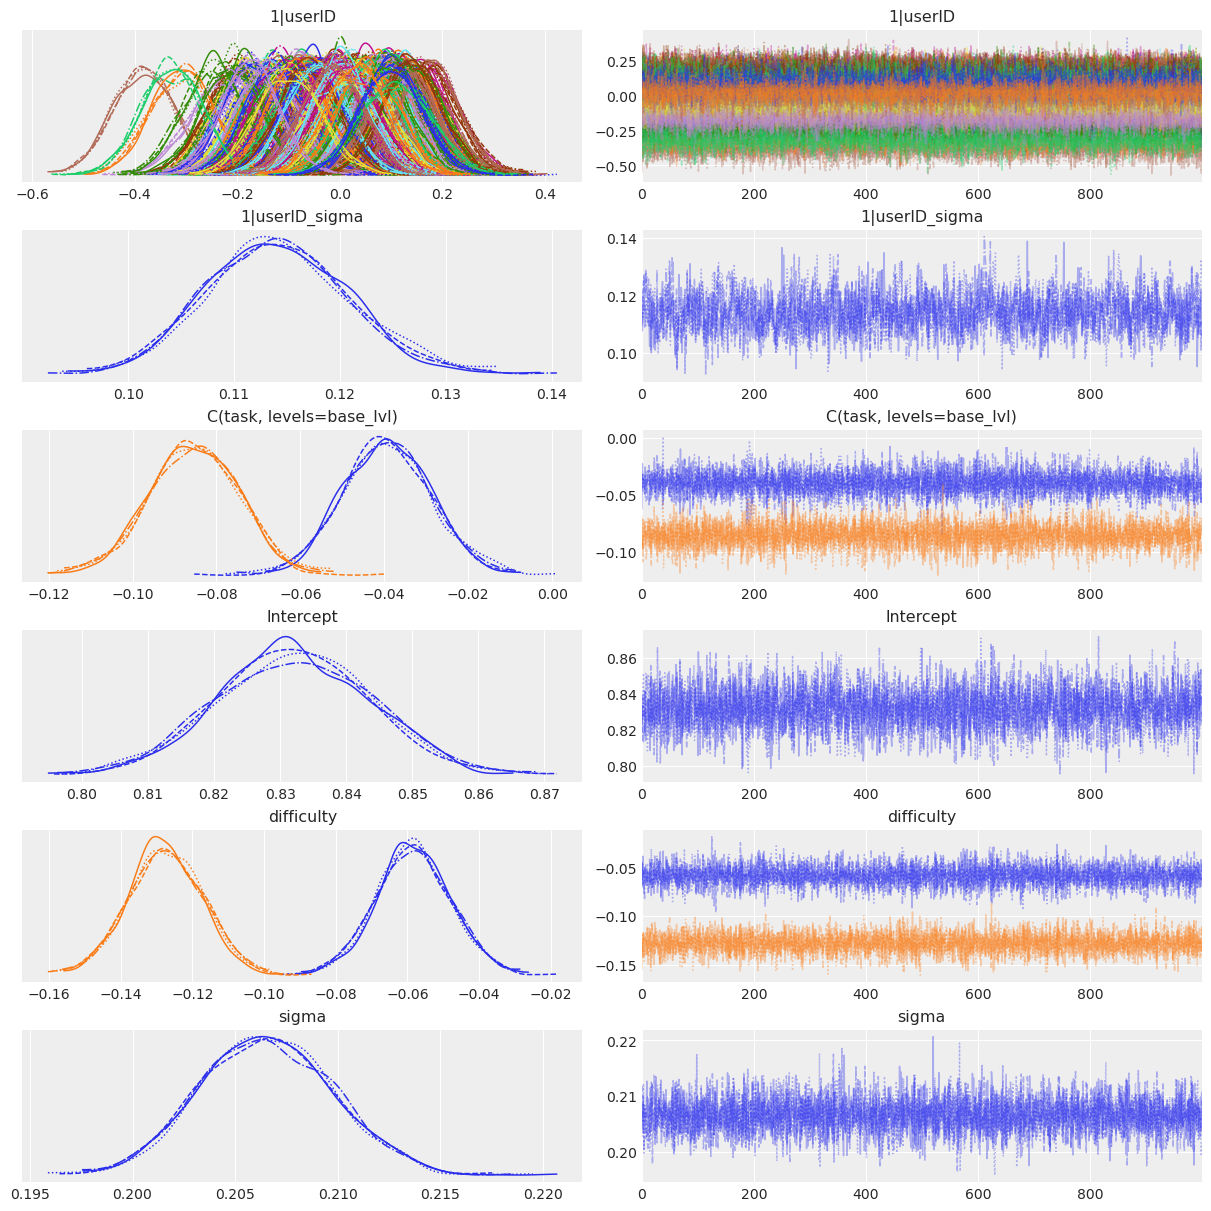

                   mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
1|userID[s_1001]  0.044  0.059  -0.066    0.155      0.001    0.001    8116.0   
1|userID[s_1002] -0.076  0.058  -0.182    0.037      0.001    0.001    6083.0   
1|userID[s_1006]  0.051  0.058  -0.055    0.164      0.001    0.001    6751.0   
1|userID[s_1012] -0.113  0.059  -0.224   -0.005      0.001    0.001    9220.0   
1|userID[s_1015]  0.012  0.058  -0.095    0.118      0.001    0.001    8978.0   
1|userID[s_1016]  0.025  0.058  -0.087    0.130      0.001    0.001    7442.0   
1|userID[s_1017] -0.112  0.060  -0.221    0.001      0.001    0.001    6933.0   
1|userID[s_1036] -0.023  0.059  -0.138    0.083      0.001    0.001    8521.0   
1|userID[s_1042] -0.168  0.059  -0.274   -0.058      0.001    0.001    7246.0   
1|userID[s_1045]  0.119  0.059   0.010    0.227      0.001    0.001    8700.0   
1|userID[s_1046] -0.097  0.069  -0.223    0.035      0.001    0.001    7957.0   
1|userID[s_1047]  0.072  0.0

In [11]:
f = 'dataset_3_other'

print(f'Dataset: {f}')
for formula in formulas2run:
    print(f'\nFitting formula {formula}\n')
    print_model(model_dic_bernoulli[f][formula], result_dic_bernoulli[f][formula])

## Dataset 3 - unmorphed image as cue stimulus
[top](#top)

Dataset: dataset_3_target_0

Fitting formula correct_flt ~ C(task, levels=base_lvl) * difficulty + (1|userID)



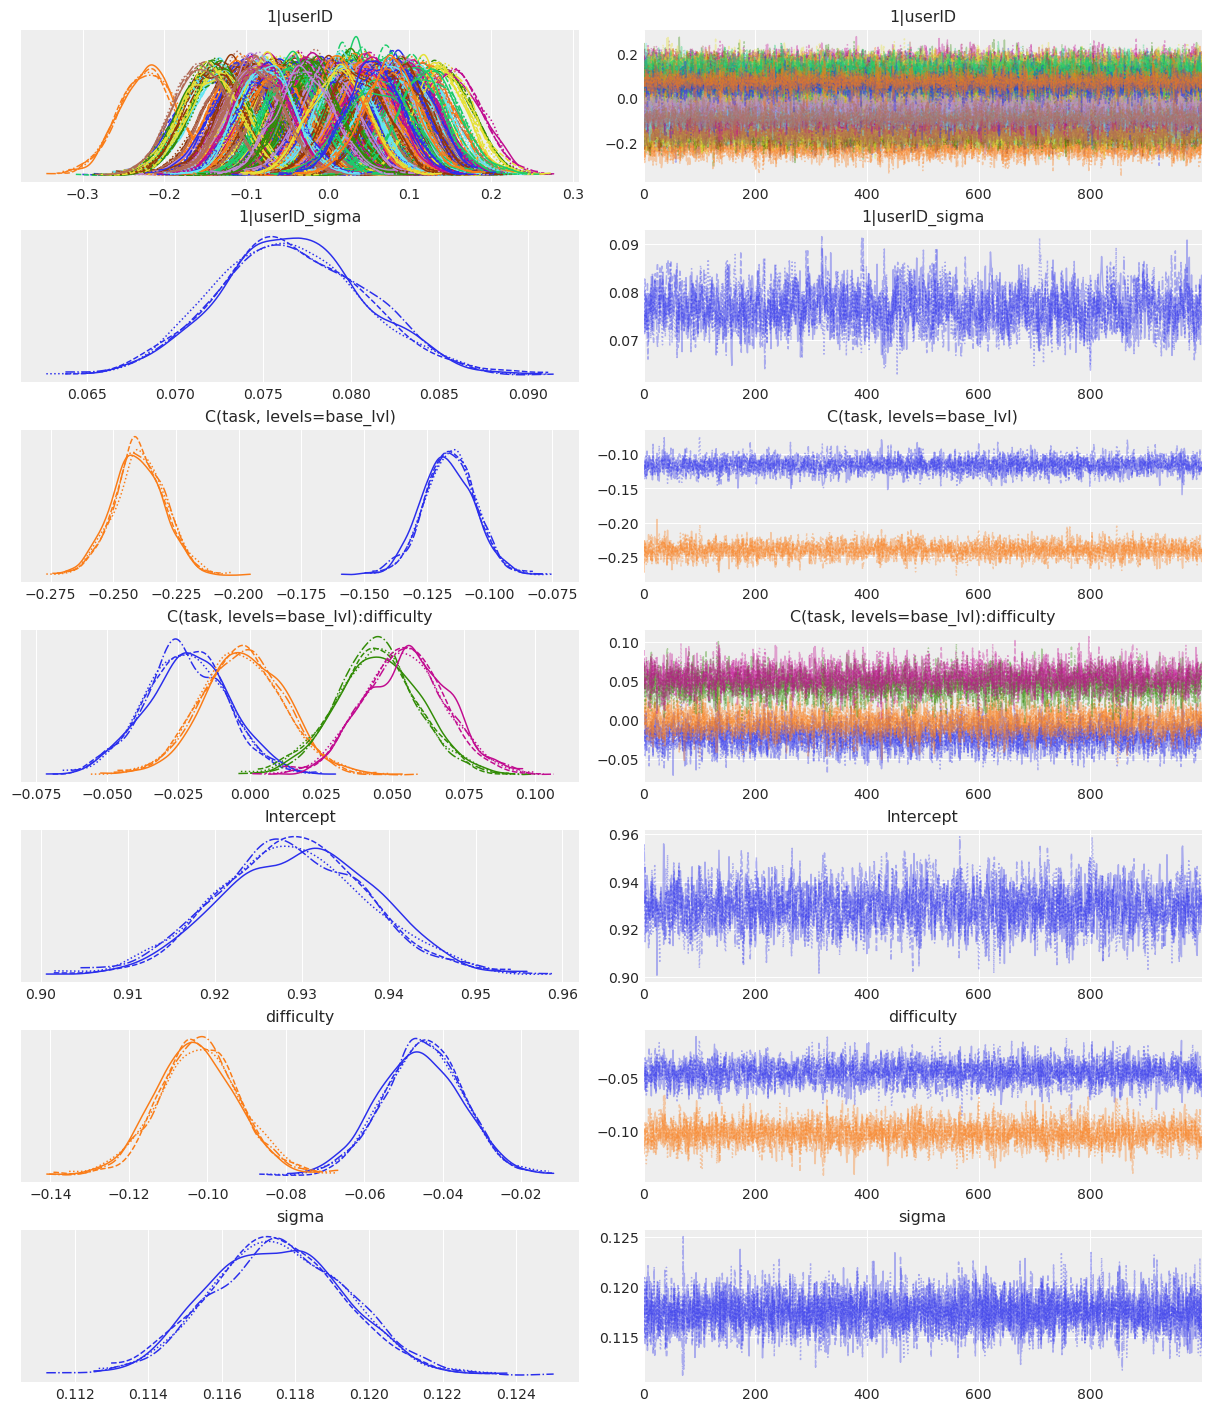

                   mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
1|userID[s_1001]  0.004  0.035  -0.060    0.069        0.0    0.001    8205.0   
1|userID[s_1002] -0.092  0.035  -0.153   -0.022        0.0    0.000    9167.0   
1|userID[s_1006]  0.019  0.036  -0.051    0.086        0.0    0.001    6802.0   
1|userID[s_1012]  0.013  0.036  -0.053    0.082        0.0    0.001    8364.0   
1|userID[s_1015] -0.026  0.036  -0.091    0.045        0.0    0.001    8509.0   
1|userID[s_1016]  0.019  0.035  -0.045    0.087        0.0    0.001    7407.0   
1|userID[s_1017] -0.023  0.035  -0.090    0.041        0.0    0.000    9133.0   
1|userID[s_1036]  0.037  0.035  -0.029    0.101        0.0    0.000    8414.0   
1|userID[s_1042]  0.082  0.035   0.018    0.147        0.0    0.000    7939.0   
1|userID[s_1045]  0.022  0.035  -0.044    0.086        0.0    0.001    7732.0   
1|userID[s_1046]  0.037  0.042  -0.046    0.110        0.0    0.001    7983.0   
1|userID[s_1047] -0.008  0.0

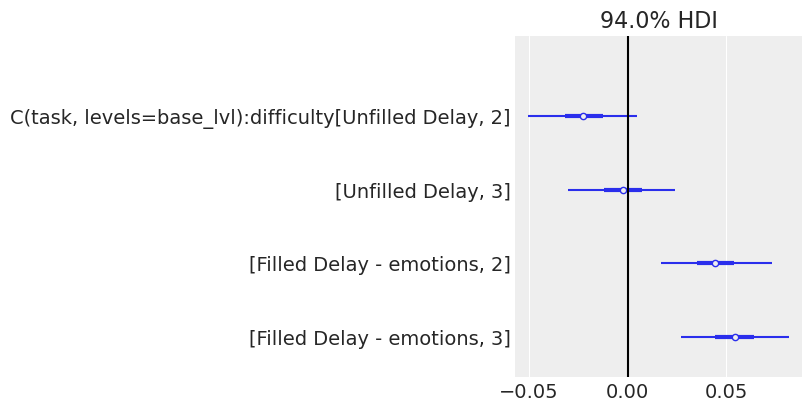

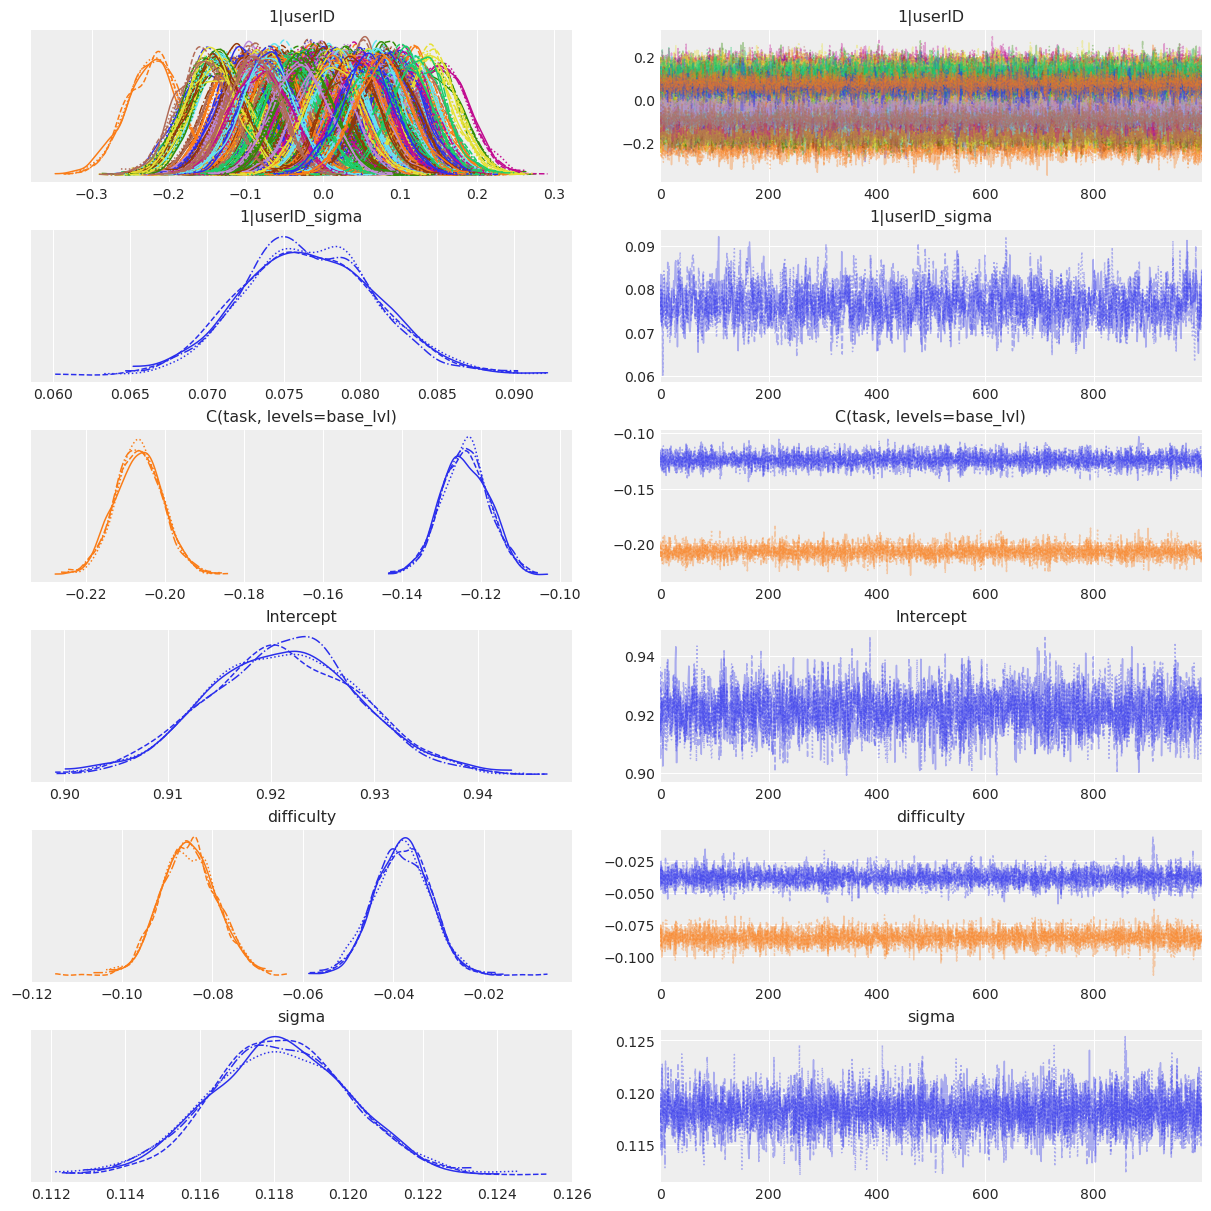

                   mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
1|userID[s_1001]  0.005  0.037  -0.066    0.072        0.0    0.001    8712.0   
1|userID[s_1002] -0.092  0.035  -0.157   -0.028        0.0    0.000    7731.0   
1|userID[s_1006]  0.019  0.035  -0.046    0.084        0.0    0.001    7976.0   
1|userID[s_1012]  0.013  0.035  -0.052    0.080        0.0    0.001    7820.0   
1|userID[s_1015] -0.026  0.036  -0.093    0.042        0.0    0.001    7998.0   
1|userID[s_1016]  0.020  0.034  -0.046    0.082        0.0    0.000    7293.0   
1|userID[s_1017] -0.024  0.035  -0.092    0.043        0.0    0.000    7880.0   
1|userID[s_1036]  0.036  0.035  -0.031    0.100        0.0    0.000    7621.0   
1|userID[s_1042]  0.082  0.035   0.020    0.148        0.0    0.000    8787.0   
1|userID[s_1045]  0.021  0.035  -0.043    0.088        0.0    0.001    6573.0   
1|userID[s_1046]  0.037  0.041  -0.038    0.114        0.0    0.001    7591.0   
1|userID[s_1047] -0.008  0.0

In [12]:
f = 'dataset_3_target_0'

print(f'Dataset: {f}')
for formula in formulas2run:
    print(f'\nFitting formula {formula}\n')
    print_model(model_dic_bernoulli[f][formula], result_dic_bernoulli[f][formula])

### Compare all data
[top](#top)

dataset_3_other 

                                                    rank    elpd_loo  \
correct_flt ~ C(task, levels=base_lvl) * diffic...     0  270.522799   
correct_flt ~ C(task, levels=base_lvl) + diffic...     1  268.034654   

                                                         p_loo  elpd_diff  \
correct_flt ~ C(task, levels=base_lvl) * diffic...  194.127742   0.000000   
correct_flt ~ C(task, levels=base_lvl) + diffic...  190.316947   2.488145   

                                                      weight         se  \
correct_flt ~ C(task, levels=base_lvl) * diffic...  0.670524  36.215945   
correct_flt ~ C(task, levels=base_lvl) + diffic...  0.329476  36.127837   

                                                         dse  warning scale  
correct_flt ~ C(task, levels=base_lvl) * diffic...  0.000000    False   log  
correct_flt ~ C(task, levels=base_lvl) + diffic...  3.837438    False   log  

dataset_3_target_0 

                                                   

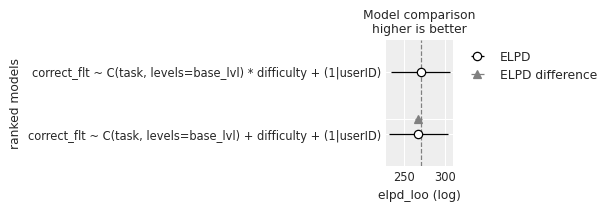

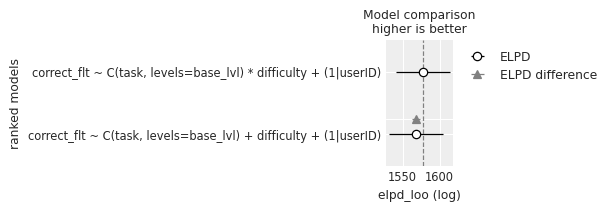

In [13]:
df_compare_formulas_bernoulli = {}
for f in result_dic_bernoulli.keys():
    print(f, '\n')
    df_compare_formulas_bernoulli[f] = az.compare(result_dic_bernoulli[f])
    
    print(df_compare_formulas_bernoulli[f])
    
    az.plot_compare(df_compare_formulas_bernoulli[f], insample_dev=False);

    
    print()
# df_compare_formulas_bernoulli[f]

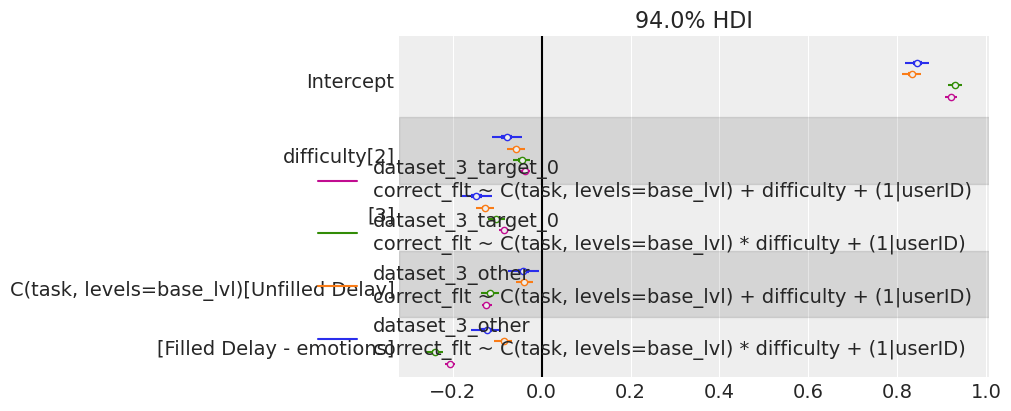

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
az.plot_forest(
    list(result_dic_bernoulli['dataset_3_other'].values())+\
    list(result_dic_bernoulli['dataset_3_target_0'].values()),
    model_names=[f'{f}\n{formula}' for f in result_dic_bernoulli.keys() for formula in formulas2run],
    var_names=["Intercept", "difficulty", "C(task, levels=base_lvl)"],
    combined=True,
    ax=ax
)

ax.axvline(0, c='k')

# manually adjust the legend, there is some weird bug
legend = ax.get_legend()
labels = [] if legend is None else [str(x._text) for x in legend.texts]
handles = [] if legend is None else legend.legend_handles
ax.legend(handles, labels, loc="lower right", bbox_to_anchor=(1., 0), ncols=1)
# plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust plot area to make space for the legend
plt.show()



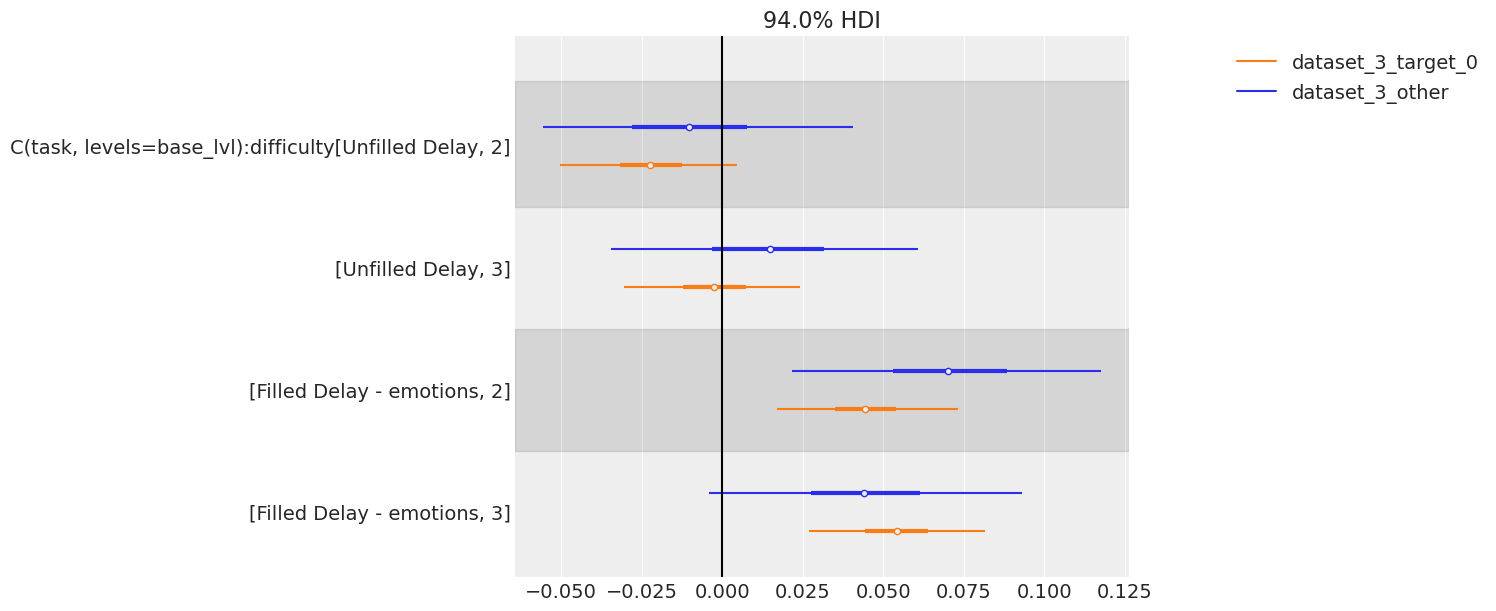

In [15]:

fig, ax = plt.subplots(figsize=(12, 6))
az.plot_forest(
    (list(result_dic_bernoulli['dataset_3_other'].values())+\
    list(result_dic_bernoulli['dataset_3_target_0'].values())
    )[::2],
    model_names=[f'{f}' for f in result_dic_bernoulli.keys()],
    var_names=["C(task, levels=base_lvl):difficulty"],
    combined=True,
#     figsize=(12, 10)
    ax=ax
);

ax.axvline(0, c='k')

# plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
# # plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust plot area to make space for the legend
# plt.show()


# manually adjust the legend, there is some weird bug
legend = ax.get_legend()
labels = [] if legend is None else [str(x._text) for x in legend.texts]
handles = [] if legend is None else legend.legend_handles
ax.legend(handles, labels, loc="upper right", bbox_to_anchor=(1.6, 1))
# plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust plot area to make space for the legend
plt.show()

### Run some predictions
[top](#top)

In [16]:
# interactions = ['delay, 2', 'delay, 3', 'interference, 2', 'interference, 3']
interactions = ['Unfilled Delay, 2', 'Unfilled Delay, 3', 'Filled Delay - emotions, 2', 'Filled Delay - emotions, 3']

d2, d3, i2, i3 = [result_dic_bernoulli[f]['correct_flt ~ C(task, levels=base_lvl) * difficulty + (1|userID)'].posterior["C(task, levels=base_lvl):difficulty"].sel({"C(task, levels=base_lvl):difficulty_dim":tsk}) for tsk in interactions]



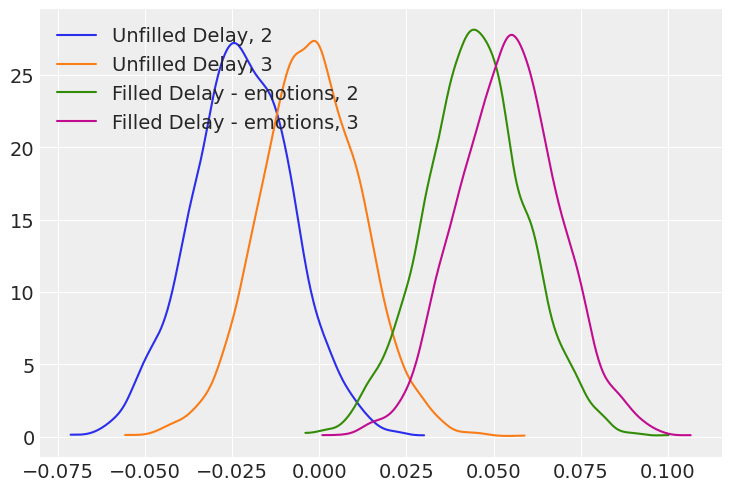

In [17]:
_, ax = plt.subplots()
for idx, x in enumerate([d2, d3, i2, i3]):
    az.plot_dist(x, label=x["C(task, levels=base_lvl):difficulty_dim"].item(), plot_kwargs={"color": f"C{idx}"}, ax=ax)
ax.legend(loc="upper left");

In [18]:
# Probability that the UD slope is less than 0

print(f"""
Probability that the UD slope is less than 0:
level 2: {(d2 < 0).mean().item()}
level 3: {(d3 < 0).mean().item()}
""")


Probability that the UD slope is less than 0:
level 2: 0.9375
level 3: 0.57675



---

In [19]:
for f in result_dic_bernoulli.keys():

    d2, d3, i2, i3 = [result_dic_bernoulli[f]['correct_flt ~ C(task, levels=base_lvl) * difficulty + (1|userID)'].posterior["C(task, levels=base_lvl):difficulty"].sel({"C(task, levels=base_lvl):difficulty_dim":tsk}) for tsk in interactions]
    print(f"""
Experiment {f}:
  Probability that the UD slope is less than 0:
    level 2: {(d2 < 0).mean().item()}
    level 3: {(d3 < 0).mean().item()}
    
  Probability that the FD-e slope is less than 0:
    level 2: {(i2 < 0).mean().item()}
    level 3: {(i3 < 0).mean().item()}
    
    """)


Experiment dataset_3_other:
  Probability that the UD slope is less than 0:
    level 2: 0.64825
    level 3: 0.2885
    
  Probability that the FD-e slope is less than 0:
    level 2: 0.00425
    level 3: 0.04175
    
    

Experiment dataset_3_target_0:
  Probability that the UD slope is less than 0:
    level 2: 0.9375
    level 3: 0.57675
    
  Probability that the FD-e slope is less than 0:
    level 2: 0.00075
    level 3: 0.0
    
    


### Save the inference
[top](#top)

It could be possible to use this:
```
result_dic_bernoulli['dataset_3_other']['correct_flt ~ task * difficulty + (1|userID)'].to_netcdf()
```

and the other datasets that were fitted, but it doesn't preserve the dictionary, so I use pickle.

In [20]:
# save the dictionary to a pickle file
with open(opj(path_inference_data,'FMP_Figure_4_cue_stim_baselineMath_inference_data_dict.pkl'), 'wb') as f:
    pickle.dump(result_dic_bernoulli, f)

In [21]:
# # Load the dictionary from the pickle file
# with open(opj(path_inference_data,'FMP_Figure_4_cue_stim_baselineMath_inference_data_dict.pkl'), 'rb') as f:
#     loaded_inference_data_dict = pickle.load(f)


In [22]:
%load_ext watermark

%watermark -a 'Jan Kadlec' -nmvu -iv -iv -w -p pytensor


Author: Jan Kadlec

Last updated: Fri May 16 2025

Python implementation: CPython
Python version       : 3.12.5
IPython version      : 8.25.0

pytensor: 2.23.0

Compiler    : GCC 12.4.0
OS          : Linux
Release     : 5.14.0-427.42.1.el9_4.x86_64
Machine     : x86_64
Processor   : x86_64
CPU cores   : 96
Architecture: 64bit

numpy     : 1.26.4
sys       : 3.12.5 | packaged by conda-forge | (main, Aug  8 2024, 18:36:51) [GCC 12.4.0]
bambi     : 0.14.0
pandas    : 2.2.2
matplotlib: 3.9.2
arviz     : 0.19.0

Watermark: 2.4.3



[top](#top)